**Group Assignment - Part A: Practical Text Pre-Processing (Q3)**

This notebook provides the practical implementations for **Q3** using embedded text data from `Data_2.txt`.

**Environment Setup**

**Environment Dependencies**

First, we ensure that all required NLTK components and necessary text processing libraries are available in the local environment.


In [1]:
import nltk
import textblob

nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
print("Environment setup and NLTK downloads complete.")

Environment setup and NLTK downloads complete.


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\junyo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\junyo\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


**Q3: Parts of Speech (POS) Taggers & Syntactic Analysers**

**Step 3.1: Load Target Sentence from Data_2.txt**

The target evaluation sentence from `Data_2.txt` is stored directly into a string variable.

In [2]:
sentence_q3 = "The big black dog barked at the white cat and chased away."

print("Target Sentence:", sentence_q3)

Target Sentence: The big black dog barked at the white cat and chased away.


**Step 3.2: Tag Sentence using NLTK, TextBlob, and Regular Expression Taggers**

We extract grammatical tags using NLTK's pre-trained tagger, TextBlob's standard properties, and a custom sequential pattern tagger to track operational alignment differences.

In [4]:
from nltk.tokenize import word_tokenize
from textblob import TextBlob

tokens_q3 = word_tokenize(sentence_q3)

nltk_tags = nltk.pos_tag(tokens_q3)

blob_obj = TextBlob(sentence_q3)
textblob_tags = [tag for tag in blob_obj.tags]

regex_rules = [
    (r'(?i)\b(the|a|an)\b', 'DT'),
    (r'(?i)\b(and)\b', 'CC'),
    (r'(?i)\b(at|in|on)\b', 'IN'),
    (r'.*ed$', 'VBD'),
    (r'.*ing$', 'VBG'),
    (r'.*s$', 'NNS'),
    (r'\b(dog|cat)\b', 'NN'),
    (r'\b(big|black|white)\b', 'JJ'),
    (r'.*', 'NN')
]
custom_regex_tagger = nltk.RegexpTagger(regex_rules)
regex_tags = custom_regex_tagger.tag(tokens_q3)

print(f"{'Word Token':<15} | {'NLTK Tag':<10} | {'TextBlob Tag':<15} | {'RegEx Tag':<10}")
print("-" * 60)
for i in range(len(tokens_q3)):
    w = tokens_q3[i]
    n_t = nltk_tags[i][1]
    
    tb_t = "None"
    for word, tag in textblob_tags:
        if word == w:
            tb_t = tag
            break
            
    r_t = regex_tags[i][1]
    print(f"{w:<15} | {n_t:<10} | {tb_t:<15} | {r_t:<10}")


Word Token      | NLTK Tag   | TextBlob Tag    | RegEx Tag 
------------------------------------------------------------
The             | DT         | DT              | DT        
big             | JJ         | JJ              | JJ        
black           | JJ         | JJ              | JJ        
dog             | NN         | NN              | NN        
barked          | VBD        | VBD             | VBD       
at              | IN         | IN              | IN        
the             | DT         | DT              | DT        
white           | JJ         | JJ              | JJ        
cat             | NN         | NN              | NN        
and             | CC         | CC              | CC        
chased          | VBD        | VBD             | VBD       
away            | RB         | RB              | NN        
.               | .          | None            | NN        


**Step 3.3: Syntactic Structural Parsing and Parse Tree Generation via Context-Free Grammar (CFG)**

We define a comprehensive Context-Free Grammar (CFG) string containing production syntax paths and lexical definitions matching our text criteria, parsing it through the `nltk.ChartParser` engine to chart individual node trees.

Processed Tokens for Chart Parser:
['the', 'big', 'black', 'dog', 'barked', 'at', 'the', 'white', 'cat', 'and', 'chased', 'away']
Total Word Tokens: 12

Hierarchical Parse Tree Structure:


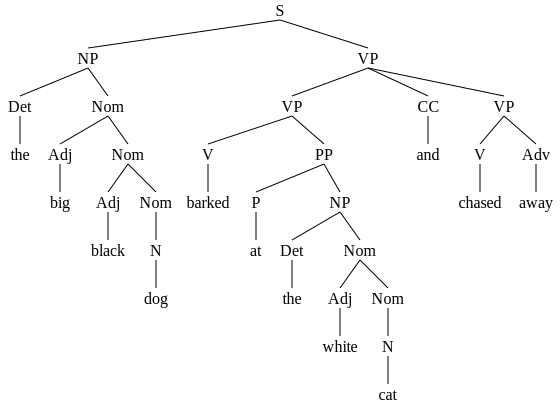

In [19]:
lowercase_tokens = [w.lower() for w in tokens_q3 if w.isalpha()]
print("Processed Tokens for Chart Parser:")
print(lowercase_tokens)
print(f"Total Word Tokens: {len(lowercase_tokens)}")

grammar_q3 = nltk.CFG.fromstring("""
S   -> NP VP
NP  -> Det Nom
Nom -> Adj Nom | N
VP  -> VP CC VP | V PP | V Adv
PP  -> P NP
Det -> 'the'
N   -> 'dog' | 'cat'
Adj -> 'big' | 'black' | 'white'
V   -> 'barked' | 'chased'
P   -> 'at'
Adv -> 'away'
CC  -> 'and'
""")

chart_parser = nltk.ChartParser(grammar_q3)

for tree in chart_parser.parse(lowercase_tokens):
    print("\nHierarchical Parse Tree Structure:")
    display(tree)